In [ ]:
import forgethreads as ft
import numpy as np



In [ ]:

rng = np.random.default_rng()
ft.set_verbose(False)


In [ ]:
# n= 100
# distribution = 0.7

# m_size = n ** 2 



# # Llenar segun distribucion

# m1= np.zeros(shape=(1,n,n))

# total_for_fill =  (n * (n-1)) / 2
# total_for_fill_pondered = total_for_fill * distribution

# ni = 0
# while(ni < total_for_fill_pondered):
#   o = rng.integers(0,n)
#   d = rng.integers(0,n)
#   if(m1[0,o,d]) == 0:
#     m1[0,o,d] = 1
#     m1[0,d,o] = 1
#     ni += 1



# m2 = m1.copy()
# paths,values, max_order = ft.maxmin(m1,m2,0.1,200,False)

In [ ]:
def create_by_distribution(n,dist):

  m1= np.zeros(shape=(1,n,n))

  total_for_fill =  (n * (n-1)) / 2
  total_for_fill_pondered = total_for_fill * dist

  ni = 0
  while(ni < total_for_fill_pondered):
    o = rng.integers(0,n)
    d = rng.integers(0,n)
    if(m1[0,o,d]) == 0:
      m1[0,o,d] = 1
      m1[0,d,o] = 1
      ni += 1
  return m1



In [ ]:
def run_experimental(n,dist):
  m1 = create_by_distribution(n,dist)
  m2 = m1.copy()
  
  paths,values, max_order = ft.maxmin(m1,m2,0.1,60,False)
  paths = paths.to_numpy()
  values = values.to_numpy()
  return max_order


In [ ]:
ns = [10,50,100,200]
dists = [0.3, 0.5, 0.7, 1.0, 1.5, 2.0, 3.0, 5.0, 8.0, 12.0, 20.0, 40.0]
iterations = 25
proms_by_n = []
for n in ns:
  proms = []
  for dist in dists:
    acum = 0
    for i in range(iterations):
      max_order = run_experimental(n,dist)
      acum += max_order
    proms.append((acum/iterations))
  print(f"calculated averages for {n} nodes")
  proms_by_n.append(proms)





KeyboardInterrupt: 

In [ ]:
proms_by_n

[[0.0, 0.08, 0.0, 0.0, 0.08, 0.04, 0.08, 0.08, 0.16, 0.04],
 [0.0, 2.4, 0.28, 0.12, 0.12, 0.08, 0.08, 0.04, 0.04, 0.04],
 [0.0, 0.4, 0.12, 0.08, 0.08, 0.04, 0.04, 0.04, 0.04, 0.04],
 [0.0, 0.2, 0.12, 0.08, 0.08, 0.04, 0.04, 0.04, 0.04, 0.04]]

In [ ]:
import matplotlib.pyplot as plt

def plot_proms(ns, dists, proms_by_n):
    plt.figure()

    for i, n in enumerate(ns):
        plt.plot(dists, proms_by_n[i], label=f"n = {n}")

    plt.xlabel("Distancia")
    plt.ylabel("Orden promedio")
    plt.title("Orden promedio vs Distancia para distintos tamaños de grafo")
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()

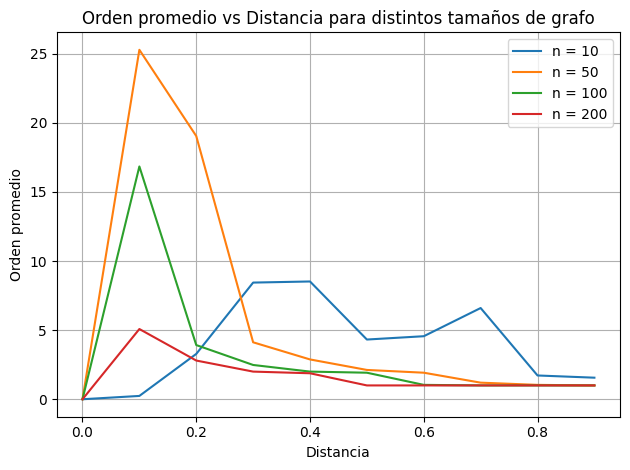

In [ ]:
plot_proms(ns,dists,proms_by_n)